# 11 — Business decision lab: model score → threshold → action → value

This notebook uses the **real digits 0-vs-1 test predictions** as a neutral stand-in for any binary scoring system. The point is not the digit business case; the point is the operating logic that is identical in fraud triage, quality inspection, lead scoring, moderation, and anomaly review.

## What you should learn
- threshold changes decisions without changing the model;
- precision/recall are operating-point properties;
- false-positive and false-negative costs can imply a threshold different from 0.5;
- review capacity creates an operational constraint;
- business KPIs must be monitored separately from training loss.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
d=load_digits();m=np.isin(d.target,[0,1]);X=d.data[m]/16.;y=(d.target[m]==1).astype(int)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.3,random_state=42,stratify=y)
# deterministic scoring model for policy analysis; ANN mechanics were learned in previous notebooks.
clf=LogisticRegression(max_iter=1000,random_state=42).fit(Xtr,ytr);scores=clf.predict_proba(Xte)[:,1]


## 1. Threshold sweep


In [2]:
thresholds=np.linspace(.05,.95,37);rows=[]
# illustrative economics per case
value_tp=10;cost_fp=3;cost_fn=14
for t in thresholds:
    pred=(scores>=t).astype(int);tn,fp,fn,tp=confusion_matrix(yte,pred).ravel();value=tp*value_tp-fp*cost_fp-fn*cost_fn
    rows.append([t,precision_score(yte,pred,zero_division=0),recall_score(yte,pred,zero_division=0),f1_score(yte,pred,zero_division=0),tn,fp,fn,tp,value,(pred==1).mean()])
policy=pd.DataFrame(rows,columns=['threshold','precision','recall','F1','TN','FP','FN','TP','illustrative value','action rate'])
best=policy.loc[policy['illustrative value'].idxmax()];best


threshold               0.300000
precision               1.000000
recall                  1.000000
F1                      1.000000
TN                     53.000000
FP                      0.000000
FN                      0.000000
TP                     55.000000
illustrative value    550.000000
action rate             0.509259
Name: 10, dtype: float64

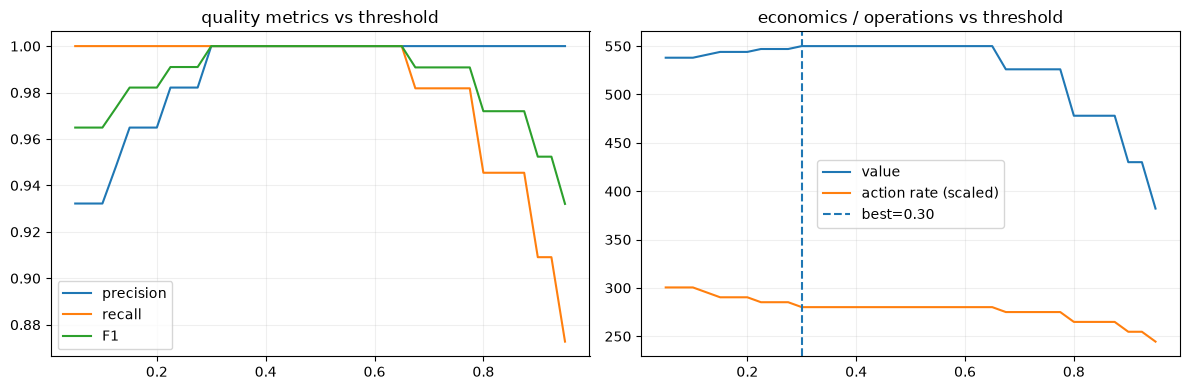

In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(policy.threshold,policy.precision,label='precision');axes[0].plot(policy.threshold,policy.recall,label='recall');axes[0].plot(policy.threshold,policy.F1,label='F1');axes[0].legend();axes[0].set_title('quality metrics vs threshold');axes[0].grid(alpha=.2)
axes[1].plot(policy.threshold,policy['illustrative value'],label='value');axes[1].plot(policy.threshold,policy['action rate']*policy['illustrative value'].max(),label='action rate (scaled)');axes[1].axvline(best.threshold,ls='--',label=f'best={best.threshold:.2f}');axes[1].legend();axes[1].set_title('economics / operations vs threshold');axes[1].grid(alpha=.2)
plt.tight_layout();plt.show()


## 2. Review-capacity policy
Suppose humans can review only the **15% most uncertain** cases. That creates a three-way policy:
- high-confidence negative → auto-negative;
- high-confidence positive → auto-positive;
- middle uncertainty band → human review.


In [4]:
uncertainty=np.abs(scores-.5);review_n=max(1,int(.15*len(scores)));review_idx=np.argsort(uncertainty)[:review_n];review=np.zeros(len(scores),dtype=bool);review[review_idx]=True
auto=~review
summary=pd.DataFrame({
    'segment':['automatic','manual review'],
    'count':[auto.sum(),review.sum()],
    'share':[auto.mean(),review.mean()],
    'mean confidence':[np.maximum(scores[auto],1-scores[auto]).mean(),np.maximum(scores[review],1-scores[review]).mean()]
});summary


,segment,count,share,mean confidence
0,automatic,92,0.851852,0.988948
1,manual review,16,0.148148,0.872207


## 3. Business inference
The neural network does **not** know the dollar cost of a false positive unless that objective was explicitly encoded into training. Usually, the safer architecture is:

**model score → calibrated policy → action → measured outcome → KPI monitoring**.

This separation lets business teams change operating policy as costs/capacity change without retraining the representation every time.


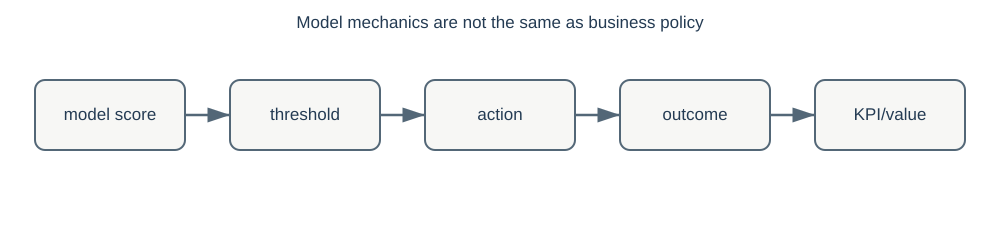

In [5]:
from pathlib import Path
from IPython.display import SVG,display
display(SVG(filename=str(Path('visual_learning')/'business_loop.svg')))


## Final ANN mental model

1. **Forward propagation:** current parameters transform the input into hidden representations and a prediction.
2. **Loss:** measures mismatch between prediction and target.
3. **Backpropagation:** attributes sensitivity of that loss to every parameter using chain rule.
4. **Optimization:** updates parameters against the gradient.
5. **Representation learning:** the updated parameters map the same raw inputs to new hidden coordinates.
6. **Inference:** freezes parameters and computes scores only.
7. **Business policy:** converts scores into actions under cost, capacity, risk, and KPI constraints.

If these seven statements are intuitive rather than memorized, the core mechanics of an ANN are no longer a black box.
